# ACDC Static B₀ Shimming — Example

This notebook demonstrates how to use the `ACDC_Optim` package to solve the
**static (single‑time‑frame) B₀ shimming problem**: given a measured or
synthetic target field inhomogeneity, find the optimal set of shim‑coil
currents that best cancels it, respecting per‑coil amplitude bounds and a
global total‑current (L1‑norm) budget.

The solver used throughout is `solve_shim_static_qp`, which formulates the
problem as a convex Quadratic Program (QP) and solves it with a dual
active‑set algorithm (`quadprog`).

**Outline**

1. Load ACDC fieldmap data
2. Build a spatial interpolator
3. Define the target region (DSV)
4. Define a target field & solve the QP
5. Visualize the shim result
6. L‑curve: sweep over current constraints

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from ACDC_Optim import solve_shim_static_qp

## 1. Load ACDC Fieldmap Data

The ACDC coil array has a set of spatial sensitivity maps (fieldmaps) stored
in a `.npz` file. Each map gives the magnetic field perturbation (Hz) per
ampere of current for one coil, sampled on a 3D grid. The mask isolates the
region of interest (e.g. the brain).

In [2]:
# load the ACDC fieldmap data
ACDC_data = np.load('ACDC_fieldmap/ACDC_3T.npz')

ACDC_fieldmap = ACDC_data['fieldmap'] # ACDC Basis fieldmap in Hz, shape (nx, ny, nz, ncoils)
mask = ACDC_data['mask'] # ACDC Mask, shape (nx, ny, nz)
xx, yy, zz = ACDC_data['xx'], ACDC_data['yy'], ACDC_data['zz'] # ACDC Coordinates, shape (nx, ny, nz)

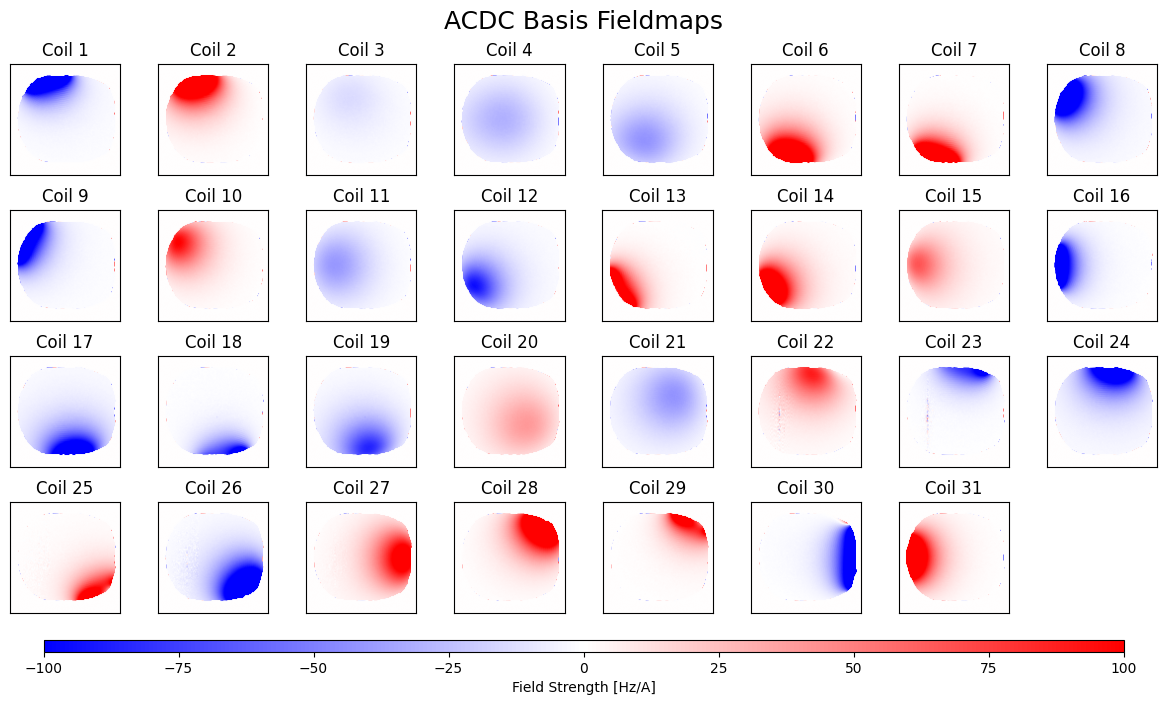

In [3]:
plt.figure(figsize=(12, 6))
for i in range(ACDC_fieldmap.shape[-1]-1):
    plt.subplot(4, 8, i + 1)
    plt.imshow(ACDC_fieldmap[..., i][:, :, ACDC_fieldmap.shape[2] // 2], cmap='bwr', origin='lower', vmin=-100, vmax=100)
    plt.xticks([])
    plt.yticks([])
    plt.title(f'Coil {i + 1}')
plt.tight_layout()
plt.suptitle('ACDC Basis Fieldmaps', fontsize=18, y=1.03)
cbar_ax = plt.gcf().add_axes([0.05, -0.04, 0.9, 0.02])
plt.colorbar(cax=cbar_ax, orientation='horizontal', label='Field Strength [Hz/A]')

## 2. Build Spatial Interpolator

The fieldmap is defined on a discrete 3D grid. To evaluate it at arbitrary
target locations we build a `RegularGridInterpolator` (trilinear
interpolation, zero outside the mask).

In [4]:
coord_x, coord_y, coord_z = xx[:, 0, 0], yy[0, :, 0], zz[0, 0, :]
ACDC_interp = RegularGridInterpolator(
    (coord_x, coord_y, coord_z), # ACDC Coordinates
    ACDC_fieldmap * mask[..., None], # ACDC Basis fieldmap masked by ACDC Mask, shape (nx, ny, nz, ncoils)
    method='linear', 
    bounds_error=False, 
    fill_value=0.0
)

## 3. Define the Target Region (DSV)

We sample the interpolated fieldmap on a grid of points inside a **D**iameter
**S**pherical **V**olume (DSV, $\varnothing = 160$ mm) restricted to a
central $z$‑slice of $\pm 35$ mm. The resulting matrix
$\mathbf{W} \in \mathbb{R}^{N_c \times N_\text{pts}}$ maps coil currents
to field perturbations at each target point.

In [5]:
dsv = 160e-3 # 16 cm DSV
n_grid = 40
z_range = 35e-3 # 35 mm z slice thickness

# Create a 3D grid of points within the DSV
xx, yy, zz = np.meshgrid(*[np.linspace(-dsv/2, dsv/2, n_grid) for _ in range(3)], indexing='ij')
r = np.column_stack([xx.ravel(), yy.ravel(), zz.ravel()])
r = r[np.linalg.norm(r, axis=1) <= dsv/2] # only keep points within the DSV
r = r[np.abs(r[:, 2]) <= z_range/2] # only keep points within the z slice thickness
print(f"Number of target field points: {r.shape[0]}")

# Interpolate the ACDC fieldmap at the target field points r, get the fieldmap basis W
W = ACDC_interp(r).T # (ncoils, n_points)
print(f"Interpolated ACDC fieldmap basis shape: {W.shape}")

Number of target field points: 9392
Interpolated ACDC fieldmap basis shape: (32, 9392)


## 4. Define a Target Field & Solve the QP

We create a synthetic quadratic target field
$B(\mathbf{r}) \propto x^2 + y^2$ (a second‑order spherical‑harmonic
pattern) and call `solve_shim_static_qp` to find the coil currents that best
cancel it.

**Constraints**

| Parameter | Value | Meaning |
|---|---|---|
| `amp_limit` | 3.0 A | Per‑coil current limit (box constraint) |
| `l1_limit` | 40.0 A | Overall current limit (L1‑ball) |

In [6]:
# Static Shim Example:
# Applying a second order target field B
B = (r[:, 0]**2 + r[:, 1]**2) * 1e5 # Target field in Hz, shape (n_points,)

current_limit = 3.0 # Current limit in Amperes
overall_current_limit = 40.0 # Overall current limit in Amperes

I_opt, nrmse = solve_shim_static_qp(B, W, current_limit, overall_current_limit)

print(f"Optimal currents shape: {I_opt.shape}")
print(f"Optimal currents sum: {np.sum(np.abs(I_opt)):.4f} A")
print(f"NRMSE: {nrmse:.4f}")

Optimal currents shape: (32,)
Optimal currents sum: 40.0000 A
NRMSE: 0.0819


In [7]:
B_ACDC = W.T @ I_opt # Estimated ACDC field in Hz, shape (n_points,)
print(f"Estimated ACDC field shape: {B_ACDC.shape}")

Estimated ACDC field shape: (9392,)


## 5. Visualize the Shim Result

The three panels show:
- **Left** — the target field $B(\mathbf{r})$
- **Centre** — the ACDC‑generated field $\mathbf{W}^T \mathbf{I}_\text{opt}$
- **Right** — the residual error $B_\text{ACDC} - B$

The bar chart shows the optimal current per coil.

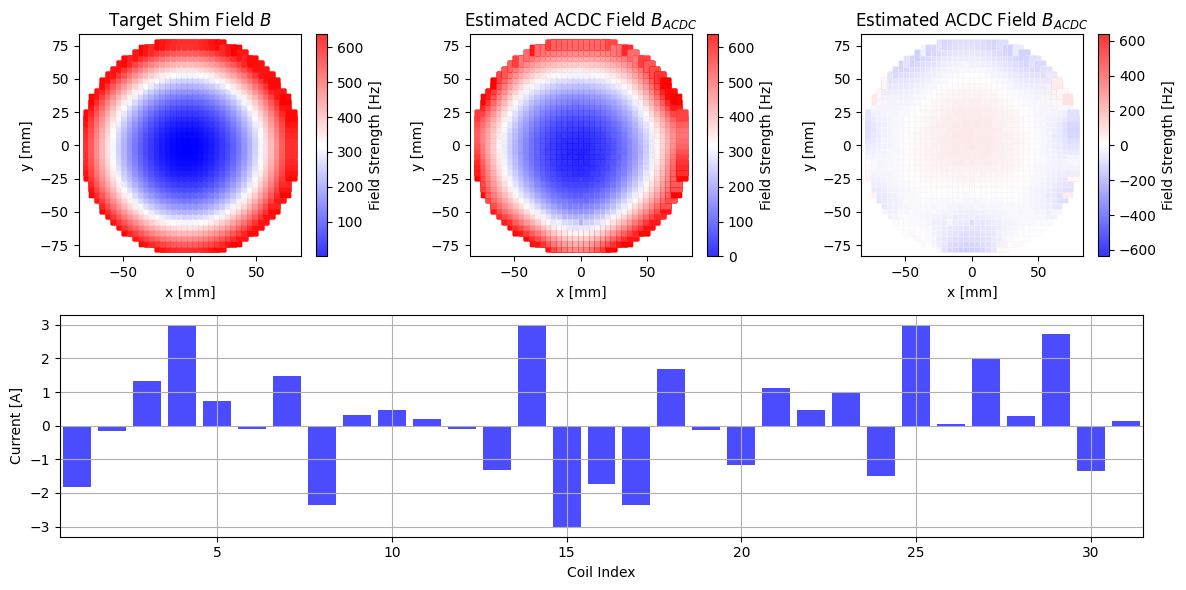

In [8]:
plt.figure(figsize=(12, 6))
plt.subplot(231, aspect='equal')
plt.scatter(r[:, 0]*1e3, r[:, 1]*1e3, c=B, cmap='bwr', s=50, marker='s', alpha=0.8)
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')
plt.colorbar(label='Field Strength [Hz]')
plt.title(r'Target Shim Field $B$')

plt.subplot(232, aspect='equal')
plt.scatter(r[:, 0]*1e3, r[:, 1]*1e3, c=B_ACDC, cmap='bwr', s=50, marker='s', alpha=0.8, vmin=0, vmax=B.max())
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')
plt.colorbar(label='Field Strength [Hz]')
plt.title(r'Estimated ACDC Field $B_{ACDC}$')

plt.subplot(233, aspect='equal')
plt.scatter(r[:, 0]*1e3, r[:, 1]*1e3, c=B_ACDC - B, cmap='bwr', s=50, marker='s', alpha=0.8, vmin=-B.max(), vmax=B.max())
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')
plt.colorbar(label='Field Strength [Hz]')
plt.title(r'Estimated ACDC Field $B_{ACDC}$')

plt.subplot(212)
plt.bar(np.arange(len(I_opt)) + 1, I_opt, color='b', alpha=0.7)
plt.xlabel('Coil Index')
plt.ylabel('Current [A]')
plt.xlim(0.5, len(I_opt) - 0.5)
plt.grid()

plt.tight_layout()
plt.show()

## 6. L‑Curve: Sweep Over Current Constraints

To understand the trade‑off between shim fidelity (NRMSE) and hardware effort,
we sweep both the per‑coil amplitude limit and the global L1 budget. The
resulting **L‑curve** shows diminishing returns as the current budget
increases — a useful guide for choosing practical operating limits.

In [9]:
current_limit_range = np.array([1.0, 1.5, 2.0, 2.5, 3.0]) # Current limit in Amperes
overall_current_limit = np.arange(10, 50, 5) # Overall current limit in Amperes

nrmse_results = np.zeros((len(current_limit_range), len(overall_current_limit)))
for idx_current_limit, idx_overall_current_limit in np.ndindex(len(current_limit_range), len(overall_current_limit)):
    I_opt, nrmse = solve_shim_static_qp(B, W, current_limit_range[idx_current_limit], overall_current_limit[idx_overall_current_limit])
    
    nrmse_results[idx_current_limit, idx_overall_current_limit] = nrmse

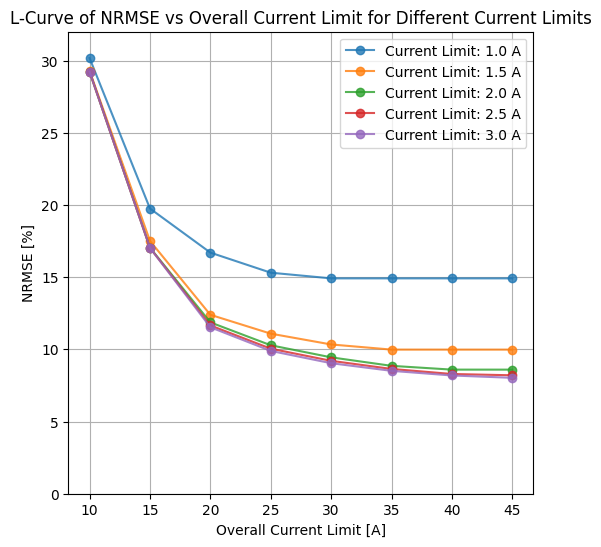

In [10]:
plt.figure(figsize=(6, 6))
for idx_current_limit in range(len(current_limit_range)):
    plt.plot(overall_current_limit, nrmse_results[idx_current_limit, :]*100, 'o-', label=f'Current Limit: {current_limit_range[idx_current_limit]} A', alpha=0.8)
plt.ylim(0, 32)
plt.legend()
plt.xlabel('Overall Current Limit [A]')
plt.ylabel('NRMSE [%]')
plt.title('L-Curve of NRMSE vs Overall Current Limit for Different Current Limits')
plt.grid()
plt.show()